In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.container import BarContainer

data= pd.read_csv('cleaned_online_retail',
                  parse_dates=["InvoiceDate"],
                  dtype={
                    "InvoiceNo": str,
                    "StockCode": str,
                    "Description": str,
                    "CustomerID": str,
                    "Country": str}
                  )
data["Quantity"] = data["Quantity"].astype(int)
data["UnitPrice"] = data["UnitPrice"].astype(float)
data["TotalAmount"] = data["TotalAmount"].astype(float)

print(data.shape)

(392692, 9)


In [9]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  str           
 7   Country      392692 non-null  str           
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 27.0 MB
None


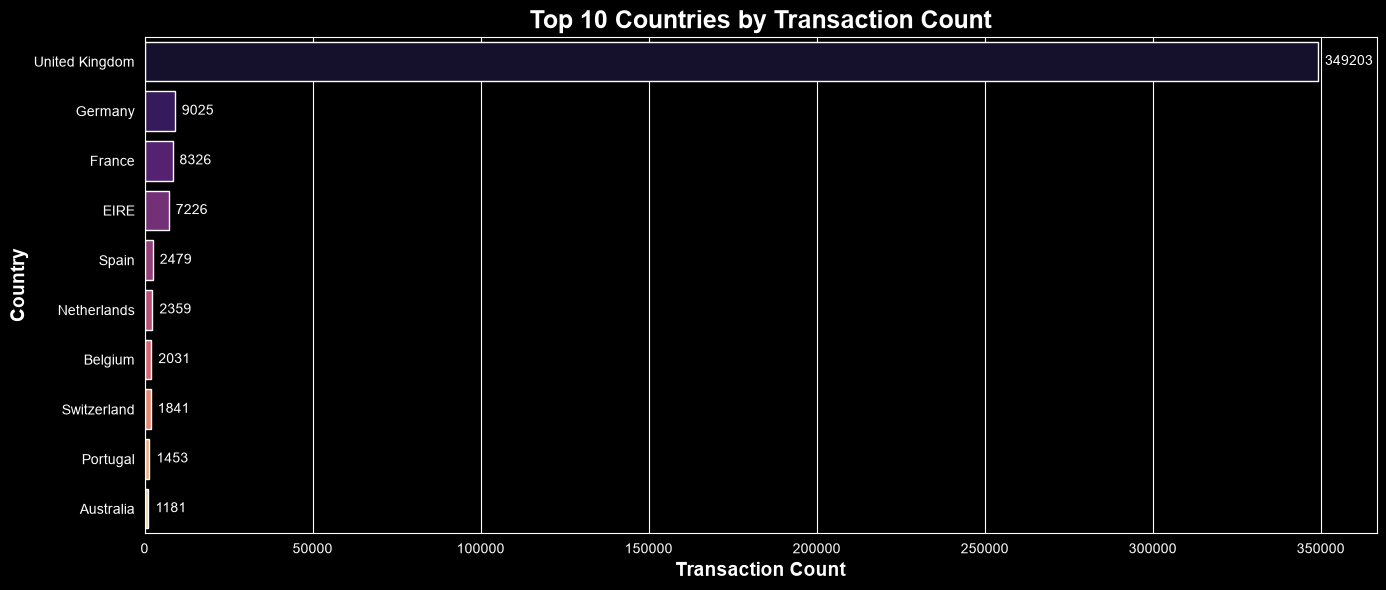

In [19]:
# Transactional Volume by Country

country_counts = data["Country"].value_counts().head(10)
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    palette="magma",
    hue=country_counts.index,
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=5, fontsize=10, color="white")
plt.title("Top 10 Countries by Transaction Count",fontsize=18,fontweight="bold")
plt.xlabel("Transaction Count",fontsize=14,fontweight="bold")
plt.ylabel("Country",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

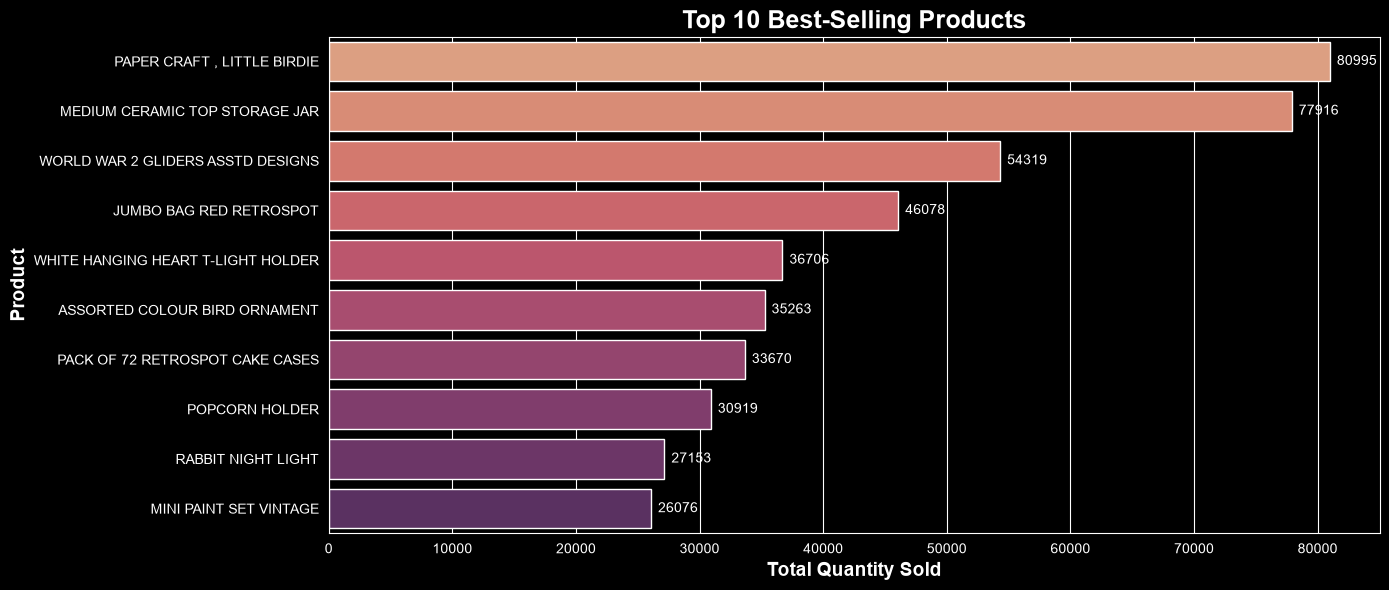

In [18]:
# Top-Selling Products

top_products = (
    data.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=top_products.values,
                y=top_products.index,
                palette="flare",
                hue=top_products.index,
                legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=5, fontsize=10, color="white")
plt.title("Top 10 Best-Selling Products",fontsize=18,fontweight="bold")
plt.xlabel("Total Quantity Sold",fontsize=14,fontweight="bold")
plt.ylabel("Product",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

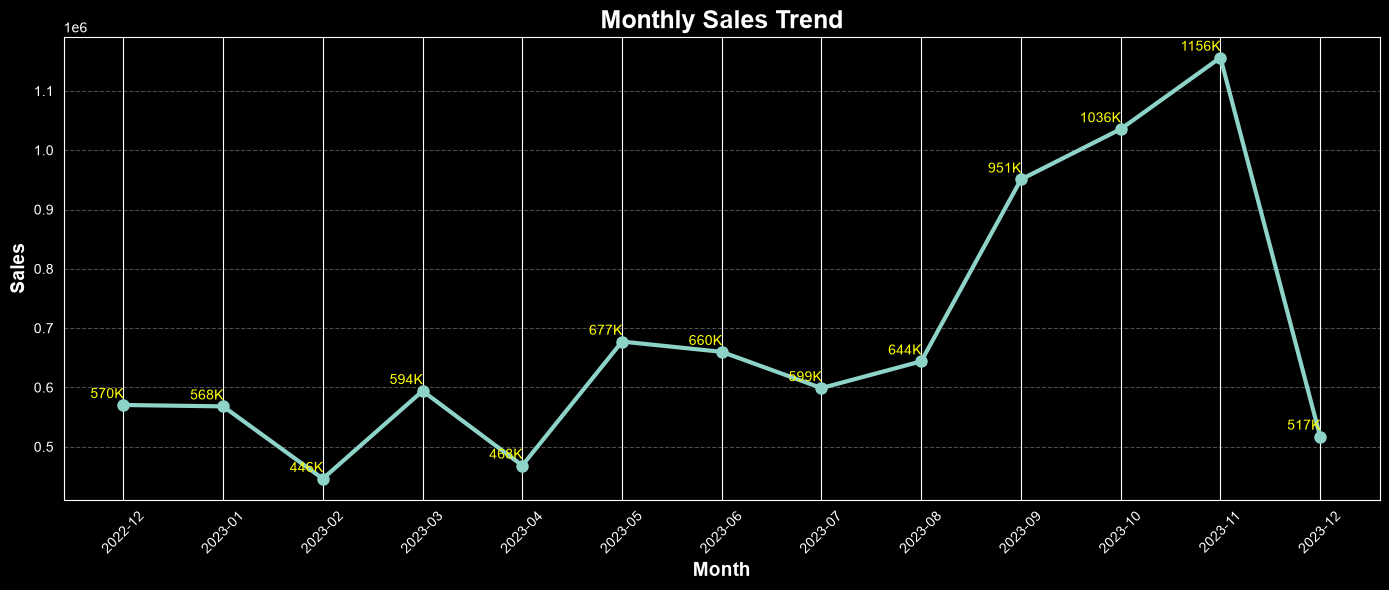

In [26]:
 # Purchase Trend over Time

data["YearMonth"] = data["InvoiceDate"].dt.to_period("M")
monthly_sales = (data.groupby("YearMonth")["TotalAmount"].sum())
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=3,
    markersize=8,
)
for i,value in enumerate(monthly_sales.values):
    plt.text(
        i,
        value + monthly_sales.max()*0.01,
        f"{value/1000:.0f}K",
        ha="right",
        fontsize=10,
        color="yellow",
    )

plt.title("Monthly Sales Trend", fontsize=18,fontweight="bold")
plt.xlabel("Month",fontsize=14,fontweight="bold")
plt.ylabel("Sales",fontsize=14,fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y",linestyle="--",alpha=0.3)
plt.tight_layout()
plt.show()

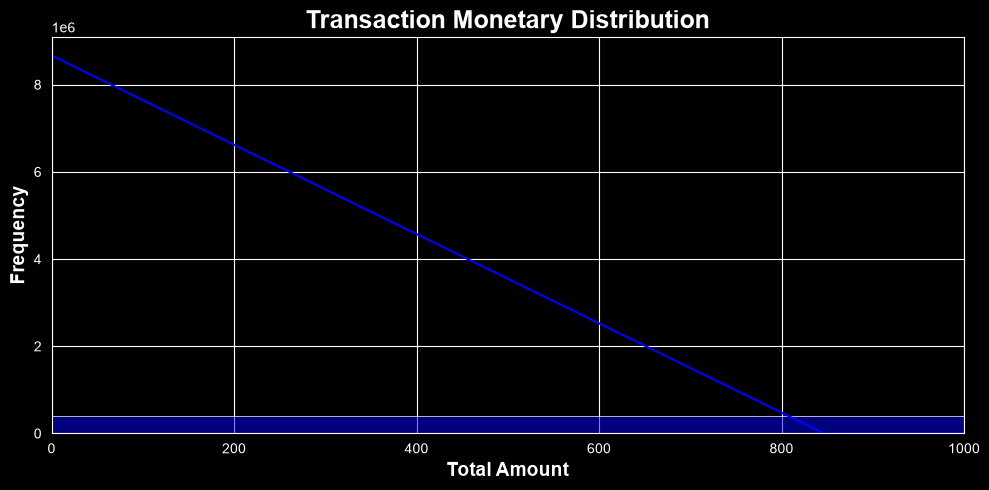

In [32]:
# Monetary Distribution

plt.figure(figsize=(10, 5))
sns.histplot(data["TotalAmount"], bins=100, kde=True,color="blue")
plt.title("Transaction Monetary Distribution",fontsize=18,fontweight="bold")
plt.xlim(0,1000)
plt.xlabel("Total Amount",fontsize=14,fontweight="bold")
plt.ylabel("Frequency",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

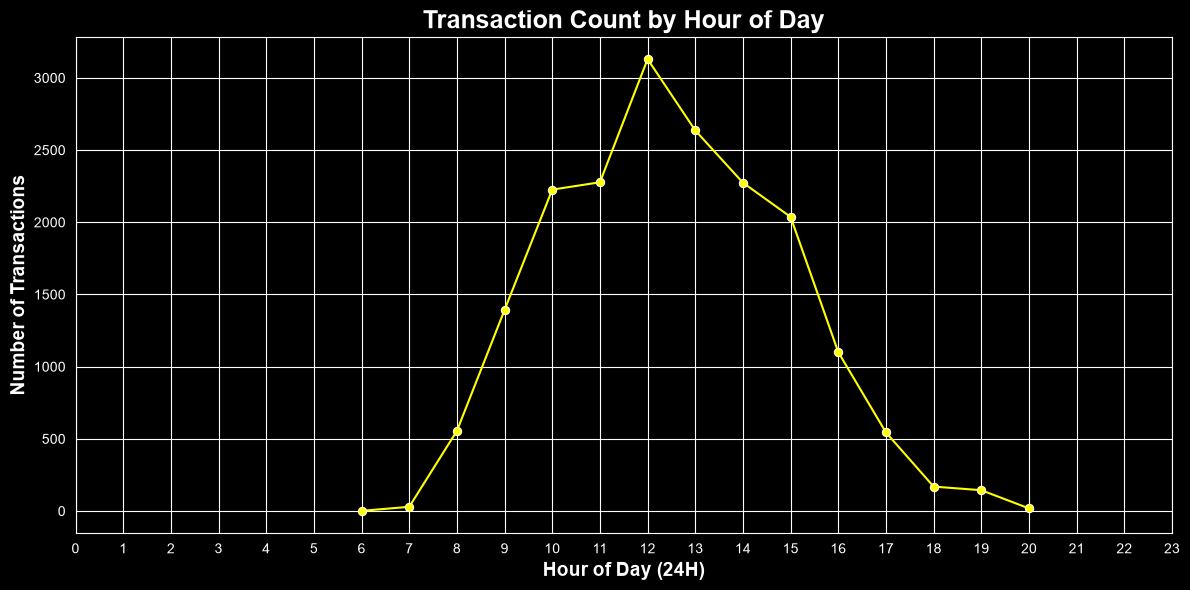

In [38]:
# Transactional Count by Hour of Day

data['InvoiceHour'] = data['InvoiceDate'].dt.hour

hourly_transactions = data.groupby('InvoiceHour')['InvoiceNo'].nunique()

plt.figure(figsize=(12,6))
sns.lineplot(
    x=hourly_transactions.index,
    y=hourly_transactions.values,
    marker="o",
    color="yellow",
)
plt.title('Transaction Count by Hour of Day',fontsize=18,fontweight="bold")
plt.xlabel('Hour of Day (24H)',fontsize=14,fontweight="bold")
plt.ylabel('Number of Transactions',fontsize=14,fontweight="bold")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()

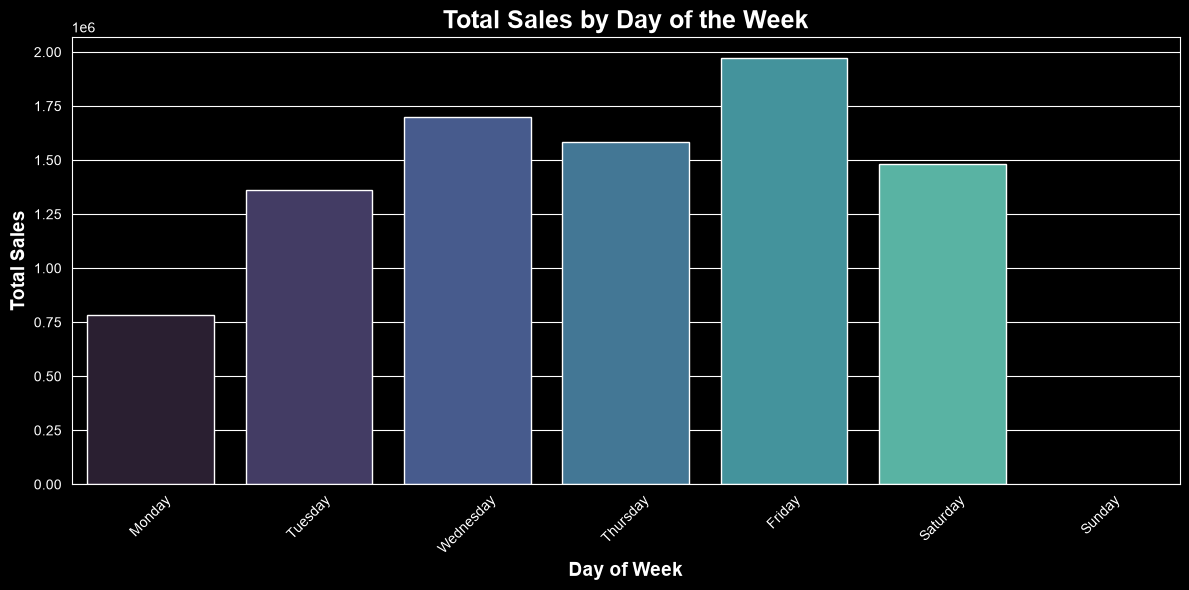

In [40]:
# Total Sales by Day of the Week

data['Weekday'] = data['InvoiceDate'].dt.day_name()

weekday_sales = data.groupby('Weekday')['TotalAmount'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    palette='mako',
    hue=weekday_sales.index,
    legend=False,
)
plt.title('Total Sales by Day of the Week',fontsize=18,fontweight="bold")
plt.xlabel('Day of Week',fontsize=14,fontweight="bold")
plt.ylabel('Total Sales',fontsize=14,fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

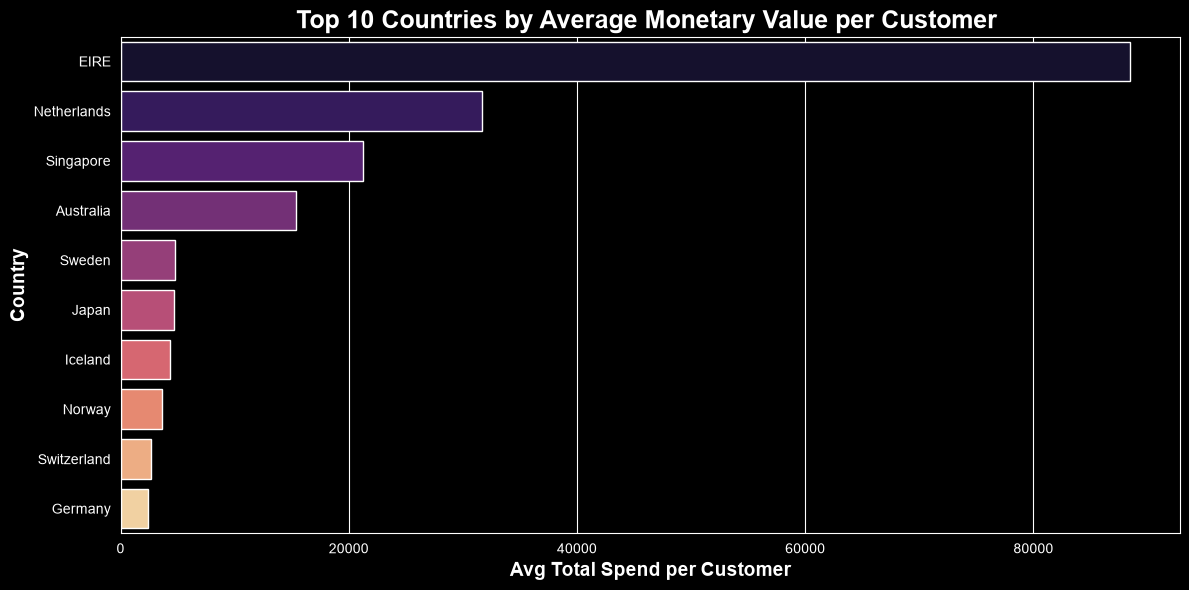

In [43]:
# Average Spend by Customer by Country

country_monetary = data.groupby(['Country','CustomerID'])['TotalAmount'].sum().reset_index()
avg_monetary_by_country = country_monetary.groupby('Country')['TotalAmount'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_monetary_by_country.values,
    y=avg_monetary_by_country.index,
    palette='magma',
    hue=avg_monetary_by_country.index,
    legend=False,
)
plt.title('Top 10 Countries by Average Monetary Value per Customer ',fontsize=18,fontweight="bold")
plt.xlabel('Avg Total Spend per Customer',fontsize=14,fontweight="bold")
plt.ylabel('Country',fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()